In [47]:
import numpy as np
from scipy.stats import kurtosis
import kaggle
from kaggle.api.kaggle_api_extended import KaggleApi
import os
import pandas as pd
from scipy.stats import gamma, lognorm, weibull_min, norm, gumbel_r, genextreme, genpareto
from scipy.optimize import minimize, approx_fprime
from numpy.linalg import inv, det

I am changing the data set to UCI Wine Quality Data, I'm going to focus on volatile acidity within red wine. 

In [18]:
df1= pd.read_csv("/Users/graysonpettit/Downloads/wine+quality/winequality-red.csv", sep=";")

In [27]:
df1.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [29]:
df1.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [41]:
DATA= df1['volatile acidity']
DATA.head()

0    0.70
1    0.88
2    0.76
3    0.28
4    0.70
Name: volatile acidity, dtype: float64

In [43]:
obs=len(DATA)
print("The number of observations is:", obs)

The number of observations is: 1599


In [49]:
mu_data = np.mean(DATA)  # formula: sum(x) / n

#Variance
var_data_pop = np.var(DATA, ddof=0)   # population variance
var_data = np.var(DATA, ddof=1)  # sample variance

# Kurtosis
kurt_val = kurtosis(DATA, fisher=True)
#standard deviation, first guess
std_data = np.std(DATA, ddof=1)

#log data
logDATA = np.log(DATA)


print("Mean:", mu_data)
print("Population Variance:", var_data_pop)
print("Sample Variance:", var_data)
print("Kurtosis:", kurt_val)
print("Standard Deviation:", std_data)

Mean: 0.5278205128205128
Population Variance: 0.03204232613332036
Sample Variance: 0.03206237765155147
Kurtosis: 1.2179633893005306
Standard Deviation: 0.17905970415353498


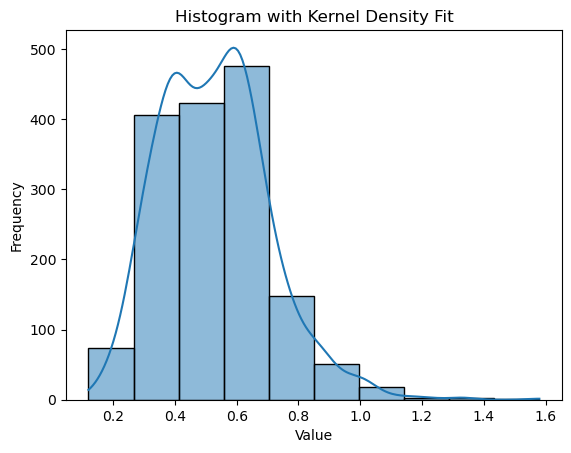

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot histogram + KDE (kernel density estimate)
sns.histplot(DATA, bins=10, kde=True)

plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram with Kernel Density Fit")
plt.show()

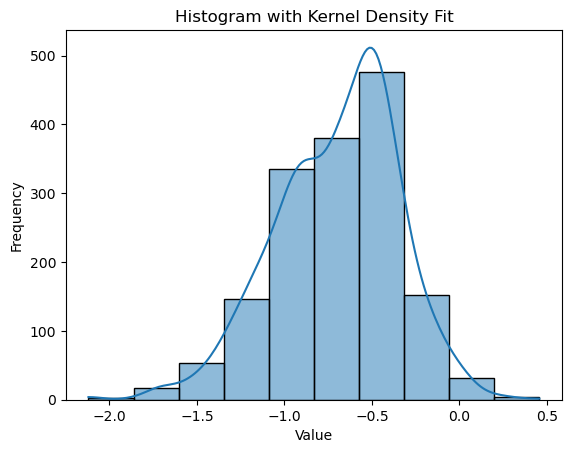

In [53]:
#plotting kernal density of log Data
sns.histplot(logDATA, bins=10, kde=True)

plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram with Kernel Density Fit")
plt.show()

In [59]:
# --- Candidate 1: Gamma Distribution (Parameters: [alpha, beta]) ---
gamma_logL = lambda theta: -np.sum(gamma.logpdf(DATA, a=theta[0], scale=theta[1]))
theta0_gamma = np.array([mu_data**2 / var_data, var_data / mu_data])

# --- Candidate 2: Log-Normal Distribution (Parameters: [mu, sigma]) ---
logL_lognormal = lambda theta: -np.sum(lognorm.logpdf(DATA, s=theta[1], scale=np.exp(theta[0])))
theta0_lognormal = np.array([
    np.mean(logDATA),   # ensure float
    np.std(logDATA, ddof=1) # ddof=1 for sample std
    ])

# --- Candidate 3: Weibull Distribution (Parameters: [scale, shape]) ---
logL_weibull = lambda theta: -np.sum(weibull_min.logpdf(DATA, c=theta[1], scale=theta[0]))
theta0_weibull = np.array([mu_data, 1.0])

# --- Candidate 4: Normal Distribution (Parameters: [mu, sigma]) ---
#logL_lognormal = lambda theta: -np.sum(lognorm.logpdf(DATA, s=abs(theta[1]), scale=np.exp(theta[0])))

logL_normal = lambda theta: -np.sum(norm.logpdf(DATA, loc=theta[0], scale=theta[1]))
theta0_normal = np.array([mu_data, std_data])

# --- Candidate 5: Extreme Value (Gumbel) Distribution (Parameters: [mu, sigma]) ---
logL_ev = lambda theta: -np.sum(gumbel_r.logpdf(DATA, loc=theta[0], scale=theta[1]))
theta0_ev = np.array([mu_data, std_data])

# --- Candidate 6: GEV Distribution (Parameters: [mu, sigma, xi]) ---
logL_gev = lambda theta: -np.sum(genextreme.logpdf(DATA, c=theta[2], loc=theta[0], scale=theta[1]))
theta0_gev = np.array([mu_data, std_data, 0.1])

# --- Candidate 7: GP Distribution (Parameters: [k, sigma, theta]) ---
logL_gppdf = lambda theta: -np.sum(genpareto.logpdf(DATA, c=theta[0], scale=theta[1], loc=theta[2]))
theta0_gppdf = np.array([0.1, std_data, np.min(DATA)])

In [55]:
#fit and select pdf function
def fit_and_select_pdf(DATA, logL_func, theta_0, dist_name):
    """
    Performs MLE, calculates Information Criteria (AIC, SBC, ICOMP_F),
    and estimates covariance from Hessian.

    Parameters
    ----------
    DATA : array-like
        The observed data vector.
    logL_func : function
        Negative log-likelihood function: logL_func(theta).
    theta_0 : list or array
        Initial guess for parameters.
    dist_name : str
        Name of the distribution.

    Returns
    -------
    AIC : float
    SBC : float
    ICOMP_F : float
    theta_hat : ndarray
    LogL_max : float
    """
    N = len(DATA)
    m = len(theta_0)

    try:
        # Minimize NEGATIVE log-likelihood
        res = minimize(logL_func, theta_0,
               method="L-BFGS-B",
               bounds=[(1e-6, None), (1e-6, None)])

        theta_hat = res.x
        negLogL_min = res.fun
        LogL_max = -negLogL_min

        # Hessian inverse (approximate covariance)
        if hasattr(res, "hess_inv"):
            H_hat_inv = res.hess_inv
            # If hess_inv is a matrix-like object (scipy returns an object sometimes)
            H_hat_inv = np.array(H_hat_inv) if not isinstance(H_hat_inv, np.ndarray) else H_hat_inv
            Sigma_hat = H_hat_inv
        else:
            Sigma_hat = np.eye(m) * np.nan  # fallback

        print(f"\n--- Results for {dist_name} ---")
        print(f"  Parameters (m): {m}")
        print(f"  Theta_hat: {np.array2string(theta_hat, precision=4)}")
        print(f"  Log-Likelihood (L_max): {LogL_max:.4f}")

    except Exception as e:
        print(f"\n--- ERROR: {dist_name} ---")
        print("  Optimization failed.")
        print("  Error:", str(e))
        return np.nan, np.nan, np.nan, np.nan, np.nan

    # --- Information Criteria ---
    AIC = -2 * LogL_max + 2 * m
    SBC = -2 * LogL_max + m * np.log(N)

    # --- ICOMP_F ---
    try:
        # Ensure symmetric covariance matrix
        Sigma_hat = (Sigma_hat + Sigma_hat.T) / 2

        eigen_Sigma = np.linalg.eigvals(Sigma_hat)
        eigen_Sigma = np.real(eigen_Sigma[np.abs(eigen_Sigma) > 1e-10])  # filter

        if len(eigen_Sigma) == 0 or np.any(eigen_Sigma < 0):
            print("  ICOMP_F: NaN (invalid eigenvalues)")
            ICOMP_F = np.nan
        else:
            mean_eigen = np.mean(eigen_Sigma)
            C1F_penalty = (1 / (4 * mean_eigen**2)) * np.sum((eigen_Sigma - mean_eigen) ** 2)
            ICOMP_F = -2 * LogL_max + C1F_penalty
    except Exception:
        ICOMP_F = np.nan

    print(f"  AIC: {AIC:.4f}")
    print(f"  SBC: {SBC:.4f}")
    print(f"  ICOMP_F: {ICOMP_F:.4f}")

    return AIC, SBC, ICOMP_F, theta_hat, LogL_max

In [61]:
# Define models
model_names = ["Gamma", "Log-Normal", "Weibull", "Normal", "Extreme Value", "GEV", "GP"]
logL_funcs = [gamma_logL, logL_lognormal, logL_weibull, logL_normal, logL_ev, logL_gev, logL_gppdf]
theta_initials = [theta0_gamma, theta0_lognormal, theta0_weibull, theta0_normal, theta0_ev, theta0_gev, theta0_gppdf]

# Prepare results DataFrame
Results = pd.DataFrame(columns=["Model", "AIC", "SBC", "ICOMP_F", "L_max"])

# Loop over models
for name, logL_func, theta0 in zip(model_names, logL_funcs, theta_initials):
    # Call your custom fitting function (must be implemented separately)
    AIC, SBC, ICOMP_F, _, L_max = fit_and_select_pdf(DATA, logL_func, theta0, name)
    
    # Append results to DataFrame
    Results.loc[len(Results)] = [name, AIC, SBC, ICOMP_F, L_max]

print(Results)


--- Results for Gamma ---
  Parameters (m): 2
  Theta_hat: [8.5642 0.0616]
  Log-Likelihood (L_max): 533.9487
  AIC: -1063.8973
  SBC: -1053.1431
  ICOMP_F: nan

--- Results for Log-Normal ---
  Parameters (m): 2
  Theta_hat: [1.000e-06 7.829e-01]
  Log-Likelihood (L_max): -760.6089
  AIC: 1525.2177
  SBC: 1535.9720
  ICOMP_F: nan

--- Results for Weibull ---
  Parameters (m): 2
  Theta_hat: [0.5893 3.1007]
  Log-Likelihood (L_max): 485.9170
  AIC: -967.8340
  SBC: -957.0797
  ICOMP_F: nan

--- Results for Normal ---
  Parameters (m): 2
  Theta_hat: [0.5278 0.179 ]
  Log-Likelihood (L_max): 481.9550
  AIC: -959.9100
  SBC: -949.1557
  ICOMP_F: nan

--- Results for Extreme Value ---
  Parameters (m): 2
  Theta_hat: [0.4432 0.1537]
  Log-Likelihood (L_max): 514.9984
  AIC: -1025.9969
  SBC: -1015.2426
  ICOMP_F: nan

--- ERROR: GEV ---
  Optimization failed.
  Error: The number of bounds is not compatible with the length of `x0`.

--- ERROR: GP ---
  Optimization failed.
  Error: The nu